# S&P 500 LPPL Analysis

Run cells top-to-bottom. No interactivity required.

Fits the Log-Periodic Power Law (Sornette 2001) in log-price space across 6 window lengths using `differential_evolution` (global optimizer). Produces 6 diagnostic plots.

In [4]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from scipy.optimize import differential_evolution
from scipy.signal import savgol_filter
import yfinance as yf

In [5]:
# ── Dates ──────────────────────────────────────────────────────────────────
END_DATE   = pd.Timestamp.today().normalize()
START_DATE = pd.Timestamp("2000-01-01")
TICKER     = "^GSPC"

# ── Fitting windows (weeks) ────────────────────────────────────────────────
WINDOWS_WEEKS = [52, 104, 156, 208, 260, 400]

# ── Savitzky-Golay smoothing ───────────────────────────────────────────────
SG_WINDOW  = 21      # must be odd; ~1 trading month
SG_POLYORD = 3

# ── Inflection / clustering ────────────────────────────────────────────────
CLUSTER_THRESHOLD_DAYS = 91
RISK_WINDOW_DAYS       = 91

# ── Differential evolution ─────────────────────────────────────────────────
DE_SEED    = 42
DE_MAXITER = 2000
DE_POPSIZE = 20
DE_TOL     = 1e-7

# ── Color palette (one per window) ────────────────────────────────────────
WINDOW_COLORS = {
    52:  "#e41a1c",
    104: "#ff7f00",
    156: "#d4b000",
    208: "#4daf4a",
    260: "#377eb8",
    400: "#984ea3",
}

print(f"END_DATE  : {END_DATE.date()}")
print(f"Windows   : {WINDOWS_WEEKS} weeks")

END_DATE  : 2026-03-13
Windows   : [52, 104, 156, 208, 260, 400] weeks


In [6]:
# ── Download ───────────────────────────────────────────────────────────────
raw = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE + pd.Timedelta(days=1),
    progress=False,
    auto_adjust=True,
)
raw = raw.reset_index()

# Flatten MultiIndex columns (yfinance quirk)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [c[0] for c in raw.columns]

raw = raw[raw["Date"] <= END_DATE].copy().reset_index(drop=True)

if raw.empty:
    raise RuntimeError(f"No data for {TICKER} between {START_DATE.date()} and {END_DATE.date()}")

# Derived columns
raw["log_close"] = np.log(raw["Close"].astype(float))
raw["sma20"]     = raw["Close"].rolling(20).mean()
raw["sma200"]    = raw["Close"].rolling(200).mean()

print(f"Loaded {len(raw):,} trading days: {raw['Date'].iloc[0].date()} → {raw['Date'].iloc[-1].date()}")
raw.tail(3)

Loaded 6,588 trading days: 2000-01-03 → 2026-03-13


,Date,Close,High,Low,Open,Volume,log_close,sma20,sma200
6585,2026-03-11,6775.799805,6811.149902,6745.589844,6790.089844,5511090000,8.821113,6852.988477,6596.159434
6586,2026-03-12,6672.620117,6740.879883,6670.399902,6740.879883,6292170000,8.805768,6839.545972,6600.508435
6587,2026-03-13,6632.189941,6733.299805,6623.919922,6673.490234,2964237000,8.799690,6829.517480,6604.061685


In [7]:
# =====================================
# MODEL FUNCTIONS
# =====================================

def lppl_log(t, A, B, C, tc, m, omega, phi):
    """LPPL in log-price space. tc must exceed all t values."""
    dt = tc - t
    return A + B * dt**m + C * dt**m * np.cos(omega * np.log(dt) + phi)


def lppl_residuals_sse(params, t, log_price):
    """SSE objective for differential_evolution (scalar minimisation)."""
    A, B, C, tc, m, omega, phi = params
    dt = tc - t
    if np.any(dt <= 0):
        return 1e20
    try:
        fitted = A + B * dt**m + C * dt**m * np.cos(omega * np.log(dt) + phi)
        return float(np.sum((log_price - fitted) ** 2))
    except Exception:
        return 1e20


def compute_metrics(log_price, fitted_log, n_params=7):
    residuals = log_price - fitted_log
    ss_res    = np.sum(residuals ** 2)
    ss_tot    = np.sum((log_price - np.mean(log_price)) ** 2)
    r2        = 1 - ss_res / ss_tot
    rmse      = np.sqrt(np.mean(residuals ** 2))
    n         = len(log_price)
    adj_r2    = 1 - (1 - r2) * (n - 1) / max(n - n_params - 1, 1)
    return {"rmse": rmse, "r2": r2, "adj_r2": adj_r2}


def tc_to_date(tc_index, df_window):
    """Convert float tc (trading-day index) → calendar date."""
    n         = len(df_window)
    last_date = df_window["Date"].iloc[-1]
    if tc_index <= n - 1:
        return df_window["Date"].iloc[min(int(round(tc_index)), n - 1)]
    calendar_days = int(round((tc_index - (n - 1)) * 7 / 5))
    return last_date + pd.Timedelta(days=calendar_days)


def find_inflections(fitted_log, df_window):
    """Return (pos_dates, neg_dates, pos_idx, neg_idx) from fitted log-price."""
    d2    = np.gradient(np.gradient(fitted_log))
    signs = np.sign(d2)
    pos_idx = np.where((signs[:-1] < 0) & (signs[1:] > 0))[0]
    neg_idx = np.where((signs[:-1] > 0) & (signs[1:] < 0))[0]
    return (
        df_window["Date"].iloc[pos_idx].values,
        df_window["Date"].iloc[neg_idx].values,
        pos_idx,
        neg_idx,
    )


def cluster_inflections(pos_dates, neg_dates, threshold_days, risk_window_days):
    """Return list of (start, end) Timestamp tuples for risk zones."""
    all_dates = np.sort(np.concatenate([pos_dates, neg_dates]))
    if len(all_dates) == 0:
        return []
    clusters, current = [], [all_dates[0]]
    for d in all_dates[1:]:
        delta = (pd.Timestamp(d) - pd.Timestamp(current[-1])).days
        if delta <= threshold_days:
            current.append(d)
        else:
            clusters.append(current)
            current = [d]
    clusters.append(current)
    zones = []
    for cluster in clusters:
        if len(cluster) < 2:
            continue
        start = pd.Timestamp(cluster[0])
        end   = pd.Timestamp(cluster[-1])
        width = (end - start).days
        if width < risk_window_days:
            expand = (risk_window_days - width) // 2
            start -= pd.Timedelta(days=expand)
            end   += pd.Timedelta(days=expand)
        zones.append((start, end))
    return zones


def _sg_window(n):
    """Compute a safe Savitzky-Golay window length for n data points."""
    w = min(SG_WINDOW, n - 2)
    if w % 2 == 0:
        w -= 1
    return max(w, SG_POLYORD + 2 if (SG_POLYORD + 2) % 2 == 1 else SG_POLYORD + 3)


print("Model functions defined.")

Model functions defined.


In [8]:
# =====================================
# FIT ALL WINDOWS
# =====================================

results = {}

for weeks in WINDOWS_WEEKS:
    start_date = END_DATE - pd.Timedelta(weeks=weeks)
    df_w = raw[raw["Date"] >= start_date].copy().reset_index(drop=True)

    if len(df_w) < 60:
        print(f"  {weeks:>4}w  SKIP  — only {len(df_w)} points")
        results[weeks] = None
        continue

    t         = np.arange(len(df_w), dtype=float)
    log_price = df_w["log_close"].values.astype(float)
    n         = len(t)

    # Savitzky-Golay smooth
    sg_win       = _sg_window(n)
    smoothed_log = savgol_filter(log_price, window_length=sg_win,
                                 polyorder=min(SG_POLYORD, sg_win - 1))

    bounds = [
        (log_price.min() - 1.0, log_price.max() + 1.0),  # A
        (-5.0, -1e-4),                                     # B  (must be < 0)
        (-1.0,  1.0),                                      # C
        (float(n + 1), float(n * 3)),                      # tc (must exceed window)
        (0.1, 0.9),                                        # m
        (6.0, 13.0),                                       # omega
        (-np.pi, np.pi),                                   # phi
    ]

    try:
        res = differential_evolution(
            lppl_residuals_sse,
            bounds,
            args=(t, log_price),
            strategy="best1bin",
            maxiter=DE_MAXITER,
            popsize=DE_POPSIZE,
            tol=DE_TOL,
            seed=DE_SEED,
            workers=1,
            polish=True,
            init="latinhypercube",
            mutation=(0.5, 1.5),
            recombination=0.9,
        )

        A, B, C, tc, m, omega, phi = res.x
        fitted_log = lppl_log(t, A, B, C, tc, m, omega, phi)
        metrics    = compute_metrics(log_price, fitted_log)
        tc_date    = tc_to_date(tc, df_w)
        days_out   = (tc_date - END_DATE).days

        results[weeks] = {
            "df":           df_w,
            "t":            t,
            "log_price":    log_price,
            "smoothed_log": smoothed_log,
            "fitted_log":   fitted_log,
            "params":       {"A": A, "B": B, "C": C, "tc": tc, "m": m, "omega": omega, "phi": phi},
            "metrics":      metrics,
            "tc_date":      tc_date,
            "days_out":     days_out,
            "sg_win":       sg_win,
            "success":      True,
        }
        print(f"  {weeks:>4}w  R²={metrics['r2']:.4f}  RMSE={metrics['rmse']:.5f}"
              f"  tc={tc_date.date()} ({days_out:+d}d)  m={m:.3f}  ω={omega:.2f}  B={B:.4f}")

    except Exception as e:
        print(f"  {weeks:>4}w  FAIL  — {e}")
        results[weeks] = {"success": False, "error": str(e)}

# ── Select best window ─────────────────────────────────────────────────────
valid = {w: r for w, r in results.items() if r and r.get("success")}

if not valid:
    raise RuntimeError("All windows failed. Check data or bounds.")

def _score(item):
    w, r = item
    bonus = 0.005 if r["days_out"] > 0 else 0.0
    return r["metrics"]["adj_r2"] + bonus

BEST_WINDOW = max(valid.items(), key=_score)[0]
print(f"\nBest window: {BEST_WINDOW}w  adj-R²={valid[BEST_WINDOW]['metrics']['adj_r2']:.4f}")

    52w  R²=0.9335  RMSE=0.02091  tc=2027-10-27 (+593d)  m=0.722  ω=9.03  B=-0.0068
   104w  R²=0.9184  RMSE=0.02707  tc=2027-04-07 (+390d)  m=0.273  ω=12.16  B=-0.2100
   156w  R²=0.9667  RMSE=0.02975  tc=2026-08-27 (+167d)  m=0.773  ω=7.17  B=-0.0033
   208w  R²=0.9434  RMSE=0.04646  tc=2033-11-12 (+2801d)  m=0.900  ω=8.83  B=-0.0001
   260w  R²=0.9159  RMSE=0.05338  tc=2030-03-30 (+1478d)  m=0.900  ω=7.99  B=-0.0008
   400w  R²=0.8968  RMSE=0.08920  tc=2040-12-21 (+5397d)  m=0.900  ω=6.00  B=-0.0007

Best window: 156w  adj-R²=0.9663


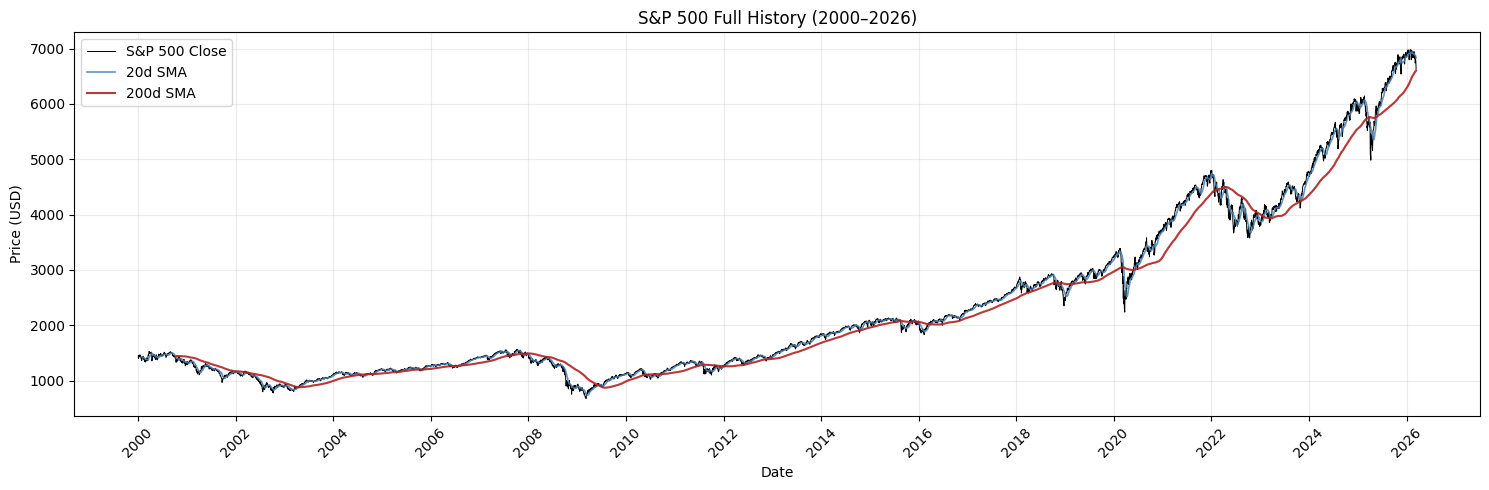

In [9]:
# =====================================
# PLOT 1 — Full History Overview
# =====================================

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(raw["Date"], raw["Close"],  color="black",      lw=0.7, label="S&P 500 Close")
ax.plot(raw["Date"], raw["sma20"],  color="steelblue",  lw=1.2, alpha=0.85, label="20d SMA")
ax.plot(raw["Date"], raw["sma200"], color="firebrick",  lw=1.5, alpha=0.9,  label="200d SMA")

ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.set_title(f"S&P 500 Full History ({START_DATE.year}–{END_DATE.year})")
ax.legend()
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

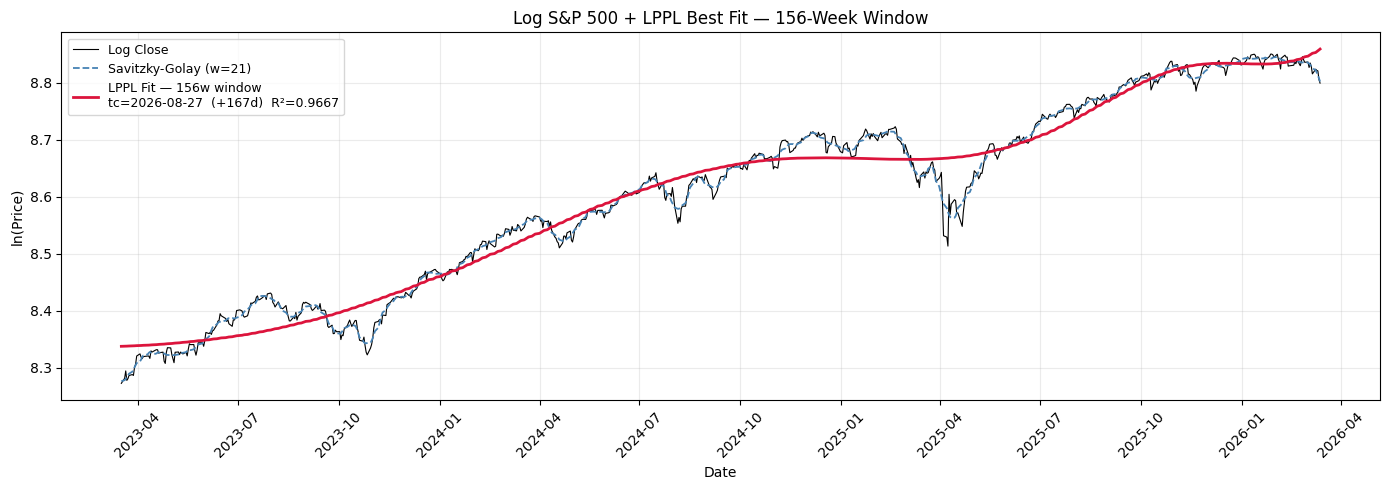

In [10]:
# =====================================
# PLOT 2 — Log-Price + Best LPPL Fit + Smoothed
# =====================================

r    = valid[BEST_WINDOW]
df_w = r["df"]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_w["Date"], r["log_price"],
        color="black",     lw=0.8, label="Log Close")
ax.plot(df_w["Date"], r["smoothed_log"],
        color="steelblue", lw=1.3, ls="--",
        label=f"Savitzky-Golay (w={r['sg_win']})")
ax.plot(df_w["Date"], r["fitted_log"],
        color="crimson",   lw=2.0,
        label=(
            f"LPPL Fit — {BEST_WINDOW}w window\n"
            f"tc={r['tc_date'].date()}  ({r['days_out']:+d}d)  "
            f"R²={r['metrics']['r2']:.4f}"
        ))

ax.set_xlabel("Date")
ax.set_ylabel("ln(Price)")
ax.set_title(f"Log S&P 500 + LPPL Best Fit — {BEST_WINDOW}-Week Window")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

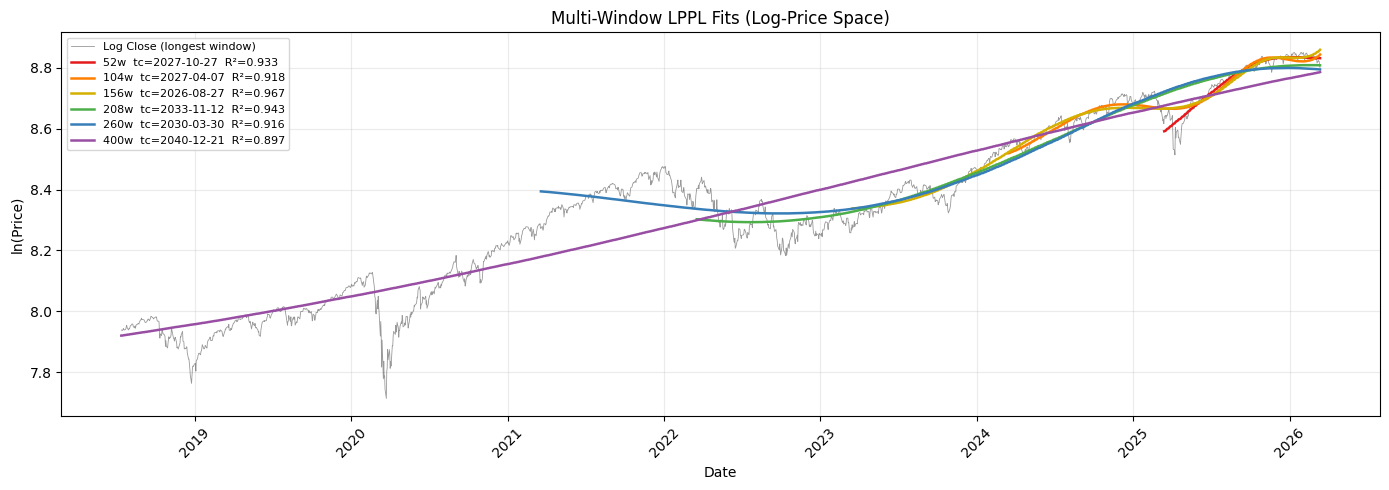

In [11]:
# =====================================
# PLOT 3 — Multi-Window LPPL Overlay
# =====================================

fig, ax = plt.subplots(figsize=(14, 5))

# Background: full log-price for the longest window
base_w  = max(valid.keys())
base_df = valid[base_w]["df"]
ax.plot(base_df["Date"], valid[base_w]["log_price"],
        color="black", lw=0.6, alpha=0.4, label="Log Close (longest window)")

for weeks in sorted(valid.keys()):
    r = valid[weeks]
    ax.plot(
        r["df"]["Date"], r["fitted_log"],
        color=WINDOW_COLORS[weeks], lw=1.8,
        label=(
            f"{weeks}w  tc={r['tc_date'].date()}"
            f"  R²={r['metrics']['r2']:.3f}"
        ),
    )

ax.set_xlabel("Date")
ax.set_ylabel("ln(Price)")
ax.set_title("Multi-Window LPPL Fits (Log-Price Space)")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

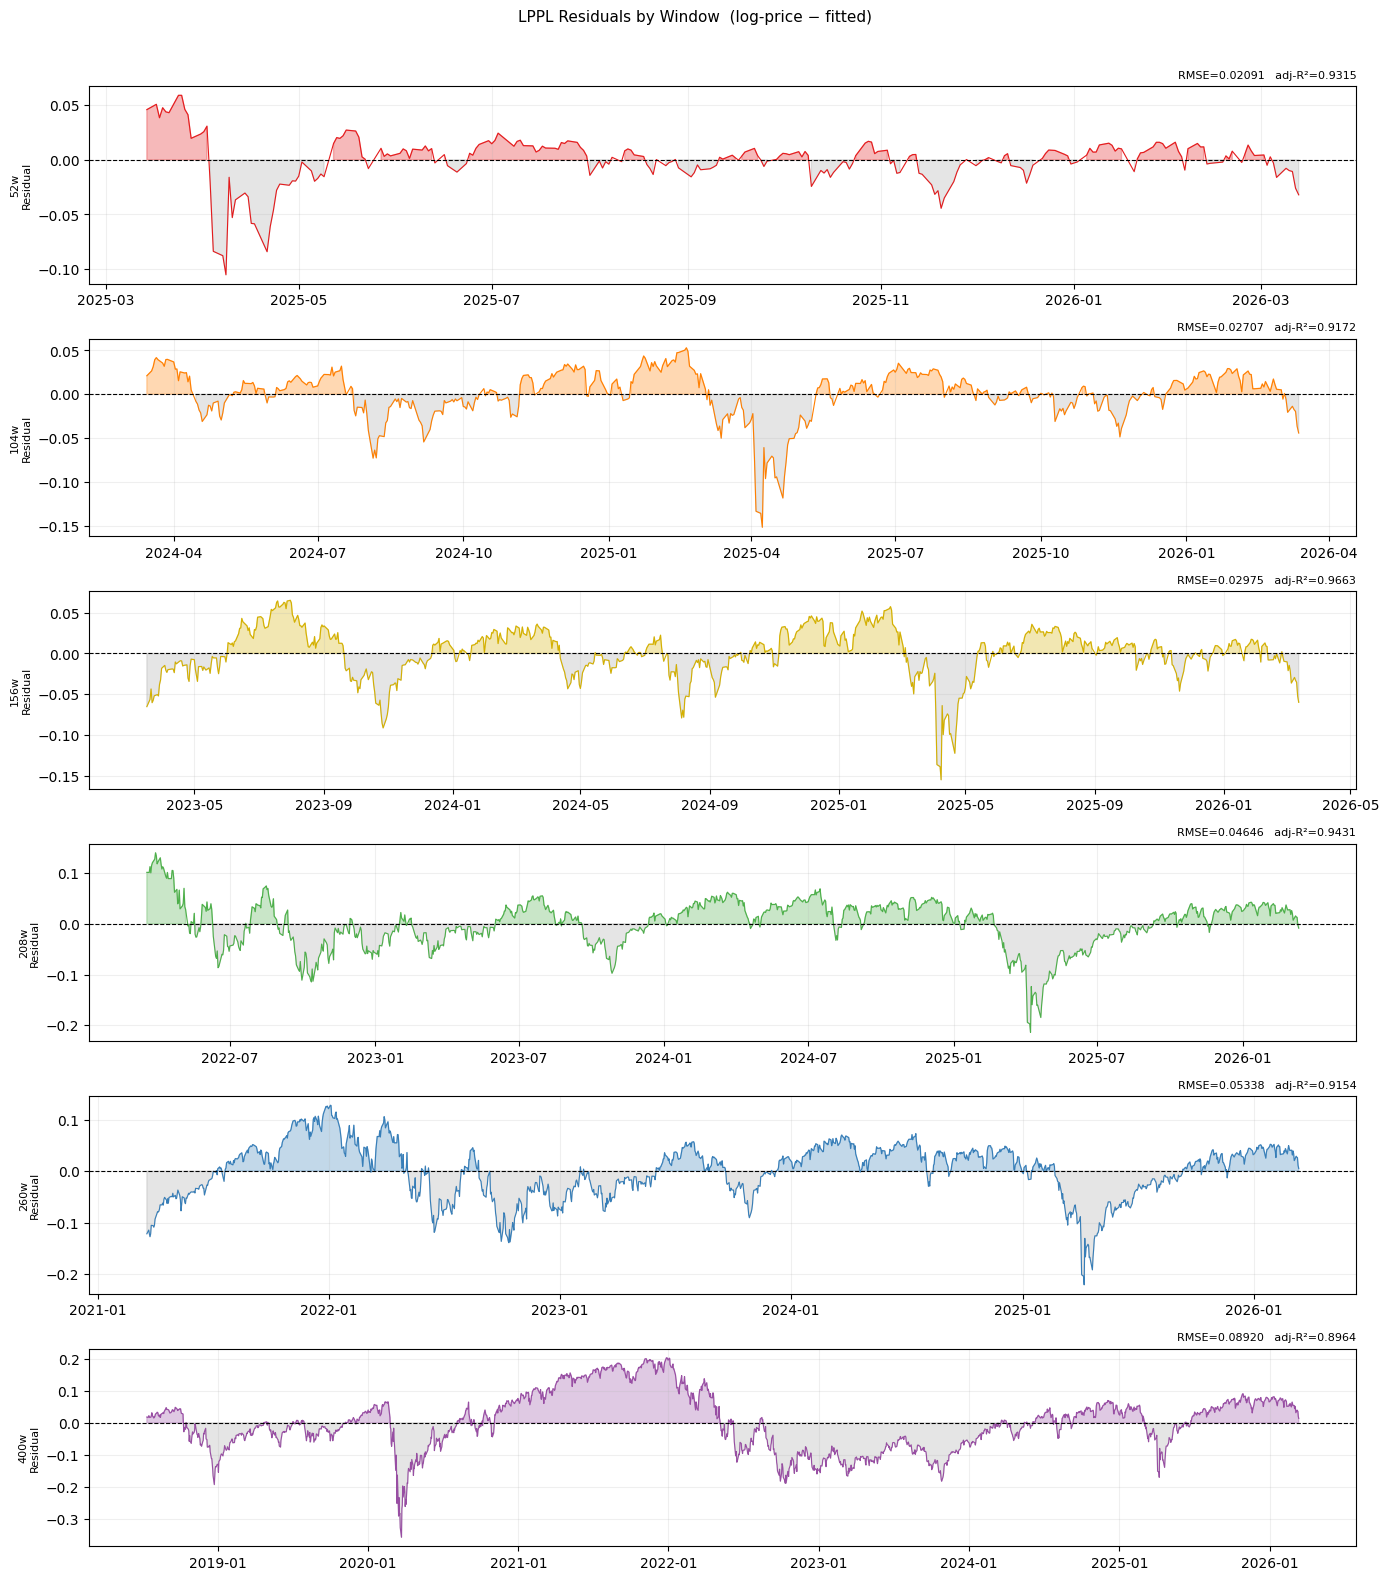

In [12]:
# =====================================
# PLOT 4 — Residuals Panel
# =====================================

n_valid = len(valid)
fig, axes = plt.subplots(n_valid, 1, figsize=(14, 2.6 * n_valid), sharex=False)
if n_valid == 1:
    axes = [axes]

for ax, (weeks, r) in zip(axes, sorted(valid.items())):
    residuals = r["log_price"] - r["fitted_log"]
    dates     = r["df"]["Date"]
    color     = WINDOW_COLORS[weeks]

    ax.plot(dates, residuals, color=color, lw=0.8)
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.fill_between(dates, residuals, 0,
                    where=(residuals > 0), color=color, alpha=0.3)
    ax.fill_between(dates, residuals, 0,
                    where=(residuals < 0), color="gray",  alpha=0.2)
    ax.set_ylabel(f"{weeks}w\nResidual", fontsize=8)
    ax.set_title(
        f"RMSE={r['metrics']['rmse']:.5f}   adj-R²={r['metrics']['adj_r2']:.4f}",
        fontsize=8, loc="right",
    )
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.suptitle("LPPL Residuals by Window  (log-price − fitted)", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

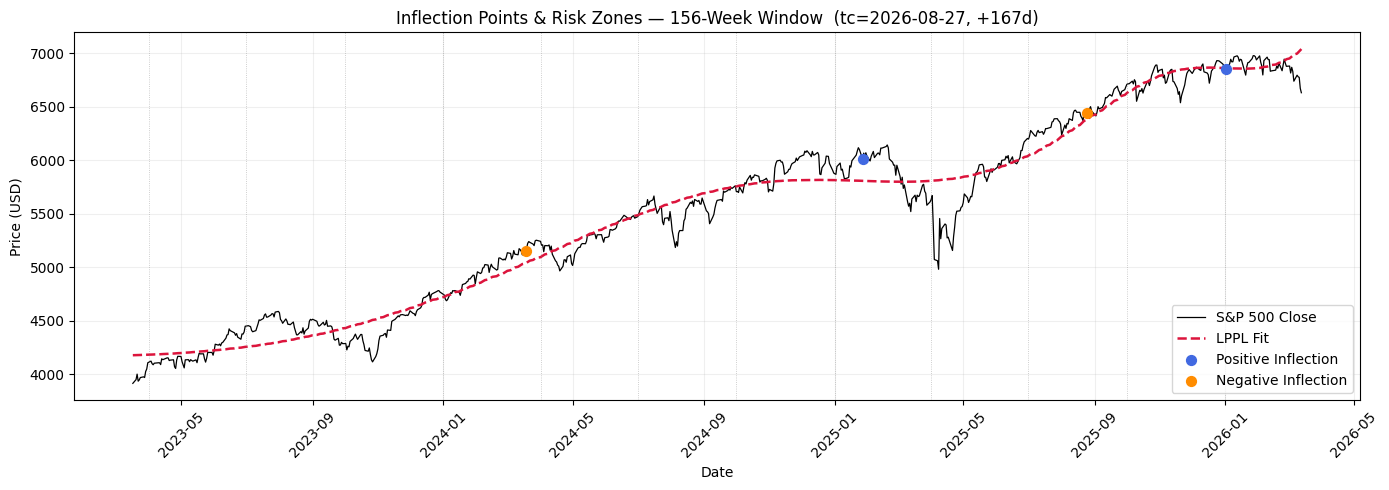

In [13]:
# =====================================
# PLOT 5 — Inflection Points & Risk Zones
# =====================================

r    = valid[BEST_WINDOW]
df_w = r["df"]

pos_dates, neg_dates, pos_idx, neg_idx = find_inflections(r["fitted_log"], df_w)
risk_zones = cluster_inflections(
    pos_dates, neg_dates,
    CLUSTER_THRESHOLD_DAYS, RISK_WINDOW_DAYS,
)

close_vals = df_w["Close"].values.astype(float)
fitted_price = np.exp(r["fitted_log"])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_w["Date"], close_vals,   color="black",   lw=0.9, label="S&P 500 Close")
ax.plot(df_w["Date"], fitted_price, color="crimson",  lw=1.8, ls="--", label="LPPL Fit")

if len(pos_idx):
    ax.scatter(df_w["Date"].iloc[pos_idx], close_vals[pos_idx],
               color="royalblue", zorder=5, s=50, label="Positive Inflection")
if len(neg_idx):
    ax.scatter(df_w["Date"].iloc[neg_idx], close_vals[neg_idx],
               color="darkorange", zorder=5, s=50, label="Negative Inflection")

for (z_start, z_end) in risk_zones:
    ax.axvspan(z_start, z_end, color="red", alpha=0.15)

for g in pd.date_range(df_w["Date"].min(), df_w["Date"].max(), freq="QS"):
    ax.axvline(g, color="gray", ls=":", lw=0.6, alpha=0.5)

ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.set_title(
    f"Inflection Points & Risk Zones — {BEST_WINDOW}-Week Window"
    f"  (tc={r['tc_date'].date()}, {r['days_out']:+d}d)"
)
ax.legend()
ax.grid(alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

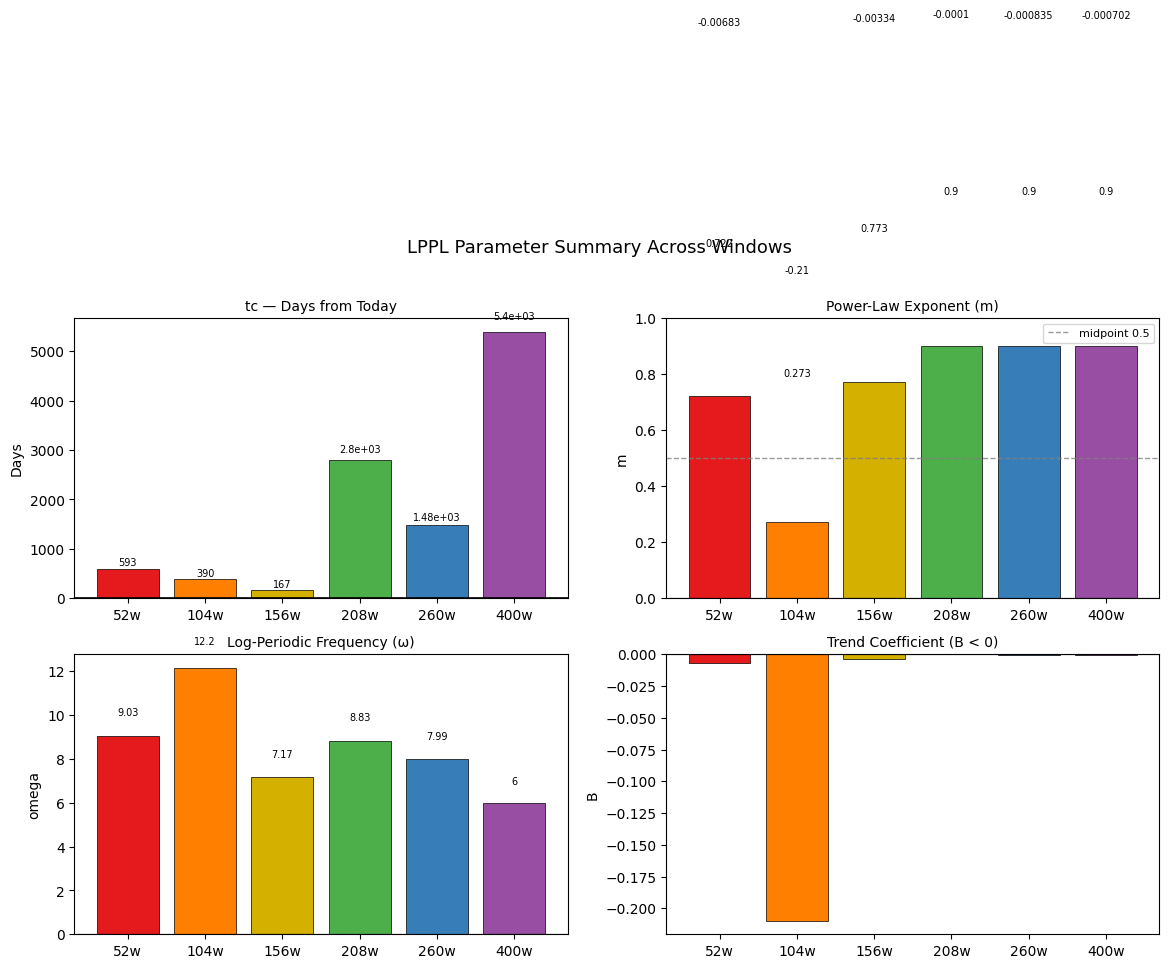


────────────────────────────────────────────────────────────────────────────────────────
  Window       R²   adj-R²       RMSE       tc Date   Days Out       m   omega         B
────────────────────────────────────────────────────────────────────────────────────────
    52w   0.9335   0.9315    0.02091    2027-10-27       +593   0.722    9.03   -0.0068
   104w   0.9184   0.9172    0.02707    2027-04-07       +390   0.273   12.16   -0.2100
   156w   0.9667   0.9663    0.02975    2026-08-27       +167   0.773    7.17   -0.0033
   208w   0.9434   0.9431    0.04646    2033-11-12      +2801   0.900    8.83   -0.0001
   260w   0.9159   0.9154    0.05338    2030-03-30      +1478   0.900    7.99   -0.0008
   400w   0.8968   0.8964    0.08920    2040-12-21      +5397   0.900    6.00   -0.0007
────────────────────────────────────────────────────────────────────────────────────────
Best window: 156w


In [14]:
# =====================================
# PLOT 6 — Parameter Summary
# =====================================

windows_sorted = sorted(valid.keys())
x      = np.arange(len(windows_sorted))
labels = [f"{w}w" for w in windows_sorted]
colors = [WINDOW_COLORS[w] for w in windows_sorted]

def _bars(ax, values, title, ylabel, color_list, hline=None, hline_label=None):
    bars = ax.bar(x, values, color=color_list, edgecolor="black", linewidth=0.5)
    if hline is not None:
        ax.axhline(hline, color="gray", lw=1.0, ls="--",
                   label=hline_label, alpha=0.8)
        ax.legend(fontsize=8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, values):
        ypos = bar.get_height() + abs(bar.get_height()) * 0.04 + 0.5
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f"{val:.3g}", ha="center", va="bottom", fontsize=7)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# tc days from today
_bars(
    axes[0, 0],
    [valid[w]["days_out"] for w in windows_sorted],
    title="tc — Days from Today",
    ylabel="Days",
    color_list=colors,
)
axes[0, 0].axhline(0, color="black", lw=1.2, ls="-")

# m parameter
_bars(
    axes[0, 1],
    [valid[w]["params"]["m"] for w in windows_sorted],
    title="Power-Law Exponent (m)",
    ylabel="m",
    color_list=colors,
    hline=0.5, hline_label="midpoint 0.5",
)
axes[0, 1].set_ylim(0, 1)

# omega
_bars(
    axes[1, 0],
    [valid[w]["params"]["omega"] for w in windows_sorted],
    title="Log-Periodic Frequency (ω)",
    ylabel="omega",
    color_list=colors,
)

# B (should be negative)
_bars(
    axes[1, 1],
    [valid[w]["params"]["B"] for w in windows_sorted],
    title="Trend Coefficient (B < 0)",
    ylabel="B",
    color_list=colors,
)

plt.suptitle("LPPL Parameter Summary Across Windows", fontsize=13)
plt.tight_layout()
plt.show()

# ── Printed summary table ──────────────────────────────────────────────────
hdr = f"{'Window':>8}  {'R²':>7}  {'adj-R²':>7}  {'RMSE':>9}  {'tc Date':>12}  {'Days Out':>9}  {'m':>6}  {'omega':>6}  {'B':>8}"
print("\n" + "─" * len(hdr))
print(hdr)
print("─" * len(hdr))
for w in windows_sorted:
    r = valid[w]
    p = r["params"]
    print(
        f"{w:>6}w  "
        f"{r['metrics']['r2']:>7.4f}  "
        f"{r['metrics']['adj_r2']:>7.4f}  "
        f"{r['metrics']['rmse']:>9.5f}  "
        f"{str(r['tc_date'].date()):>12}  "
        f"{r['days_out']:>+9d}  "
        f"{p['m']:>6.3f}  "
        f"{p['omega']:>6.2f}  "
        f"{p['B']:>8.4f}"
    )
print("─" * len(hdr))
print(f"Best window: {BEST_WINDOW}w")

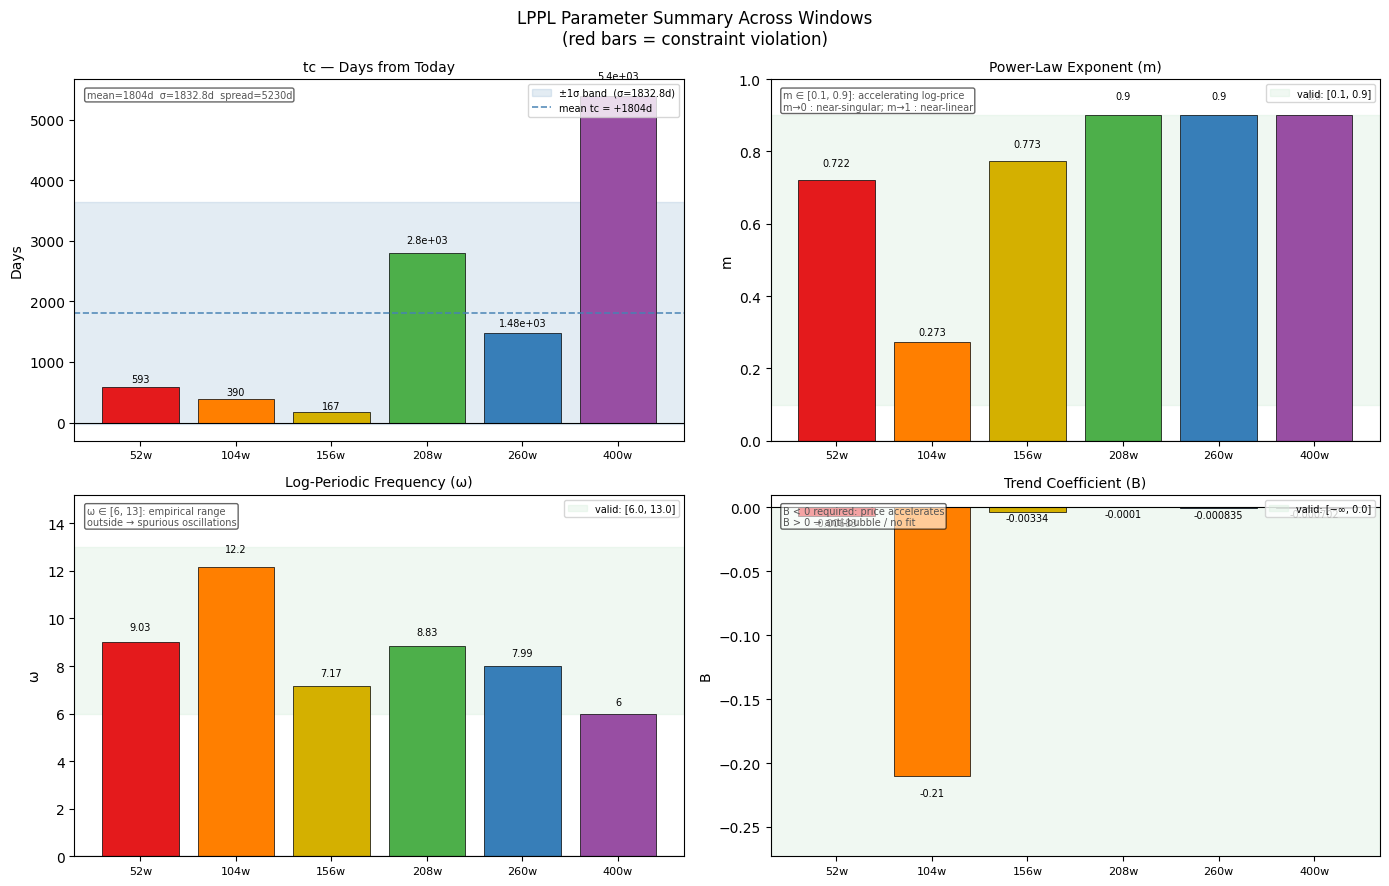


────────────────────────────────────────────────────────────────────────────────────────────────────────
  Window       R²   adj-R²       RMSE       tc Date   Days Out       m       ω         B     Constraints
────────────────────────────────────────────────────────────────────────────────────────────────────────
    52w   0.9335   0.9315    0.02091    2027-10-27       +593   0.722    9.03   -0.0068    ✓m  ✓omega  ✓B
   104w   0.9184   0.9172    0.02707    2027-04-07       +390   0.273   12.16   -0.2100    ✓m  ✓omega  ✓B
   156w   0.9667   0.9663    0.02975    2026-08-27       +167   0.773    7.17   -0.0033    ✓m  ✓omega  ✓B
   208w   0.9434   0.9431    0.04646    2033-11-12      +2801   0.900    8.83   -0.0001    ✓m  ✓omega  ✓B
   260w   0.9159   0.9154    0.05338    2030-03-30      +1478   0.900    7.99   -0.0008    ✓m  ✓omega  ✓B
   400w   0.8968   0.8964    0.08920    2040-12-21      +5397   0.900    6.00   -0.0007    ✓m  ✓omega  ✓B
────────────────────────────────────────────────

In [15]:
# =====================================
# PLOT 6 — Parameter Summary (rigorous)
# =====================================

# ── Canonical LPPL validity bounds (Johansen-Sornette 1999/2010) ──────────
BOUNDS = {
    "m":     (0.1, 0.9),
    "omega": (6.0, 13.0),
    "B":     (None, 0.0),   # B must be strictly negative
}

def _check_constraints(p):
    """Returns dict of {param: bool} indicating constraint satisfaction."""
    return {
        "m":     BOUNDS["m"][0]     <= p["m"]     <= BOUNDS["m"][1],
        "omega": BOUNDS["omega"][0] <= p["omega"] <= BOUNDS["omega"][1],
        "B":     p["B"] < BOUNDS["B"][1],
    }

def _constraint_summary(p):
    checks = _check_constraints(p)
    return "✓" if all(checks.values()) else "✗[" + ",".join(k for k,v in checks.items() if not v) + "]"

windows_sorted = sorted(valid.keys())
x      = np.arange(len(windows_sorted))
labels = [f"{w}w" for w in windows_sorted]

# Color bars by full constraint satisfaction (not just window)
def _bar_colors(param_key=None):
    out = []
    for w in windows_sorted:
        p = valid[w]["params"]
        ok = _check_constraints(p)
        if param_key:
            c = WINDOW_COLORS[w] if ok[param_key] else "#d9534f"  # red = violation
        else:
            c = WINDOW_COLORS[w] if all(ok.values()) else "#d9534f"
        out.append(c)
    return out

def _bars(ax, values, title, ylabel, color_list,
          valid_band=None, vline_zero=False, note=None):
    """
    valid_band : (lo, hi) — shade the canonical valid region
    vline_zero : draw a horizontal zero line with semantic weight
    note       : small annotation string in corner
    """
    if valid_band is not None:
        lo, hi = valid_band
        # If one-sided (hi only), shade from axis bottom
        ylo = lo if lo is not None else ax.get_ylim()[0] - 1e9
        yhi = hi if hi is not None else ax.get_ylim()[1] + 1e9
        ax.axhspan(ylo, yhi, color="#d4edda", alpha=0.35, zorder=0,
                   label=f"valid: [{lo if lo is not None else '−∞'}, "
                         f"{hi if hi is not None else '+∞'}]")

    bars = ax.bar(x, values, color=color_list, edgecolor="black",
                  linewidth=0.5, zorder=2)
    ax.axhline(0, color="black", lw=0.8, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)

    for bar, val in zip(bars, values):
        sign   = 1 if val >= 0 else -1
        offset = abs(bar.get_height()) * 0.04 + 0.003 * (ax.get_ylim()[1] - ax.get_ylim()[0])
        ypos   = bar.get_height() + sign * offset
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f"{val:.3g}", ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=7)

    if valid_band is not None:
        ax.legend(fontsize=7, loc="upper right")

    if note:
        ax.text(0.02, 0.97, note, transform=ax.transAxes,
                fontsize=7, va="top", color="#555555",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))

# ── tc convergence statistics ──────────────────────────────────────────────
tc_days   = np.array([valid[w]["days_out"] for w in windows_sorted])
tc_mean   = tc_days.mean()
tc_std    = tc_days.std()
tc_spread = tc_days.max() - tc_days.min()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── [0,0]  tc — Days from Today ─────────────────────────────────────────
_bars(
    axes[0, 0],
    tc_days,
    title="tc — Days from Today",
    ylabel="Days",
    color_list=_bar_colors(),
    note=f"mean={tc_mean:.0f}d  σ={tc_std:.1f}d  spread={tc_spread:.0f}d"
)
# Consensus band: ±1σ around mean tc — tight clustering is the key signal
axes[0, 0].axhspan(tc_mean - tc_std, tc_mean + tc_std,
                   color="steelblue", alpha=0.15, zorder=0,
                   label=f"±1σ band  (σ={tc_std:.1f}d)")
axes[0, 0].axhline(tc_mean, color="steelblue", lw=1.2, ls="--", alpha=0.9,
                   label=f"mean tc = {tc_mean:+.0f}d")
axes[0, 0].legend(fontsize=7, loc="upper right")

# ── [0,1]  m — Power-Law Exponent ────────────────────────────────────────
m_vals = [valid[w]["params"]["m"] for w in windows_sorted]
axes[0, 1].set_ylim(0, 1)
_bars(
    axes[0, 1],
    m_vals,
    title="Power-Law Exponent (m)",
    ylabel="m",
    color_list=_bar_colors("m"),
    valid_band=BOUNDS["m"],
    note="m ∈ [0.1, 0.9]: accelerating log-price\nm→0 : near-singular; m→1 : near-linear"
)

# ── [1,0]  omega — Log-Periodic Frequency ─────────────────────────────────
om_vals = [valid[w]["params"]["omega"] for w in windows_sorted]
axes[1, 0].set_ylim(0, max(om_vals) * 1.25)
_bars(
    axes[1, 0],
    om_vals,
    title="Log-Periodic Frequency (ω)",
    ylabel="ω",
    color_list=_bar_colors("omega"),
    valid_band=BOUNDS["omega"],
    note="ω ∈ [6, 13]: empirical range\noutside → spurious oscillations"
)

# ── [1,1]  B — Trend Coefficient ──────────────────────────────────────────
b_vals = [valid[w]["params"]["B"] for w in windows_sorted]
axes[1, 1].set_ylim(min(b_vals) * 1.3, max(b_vals) * 1.3 + 0.01)
_bars(
    axes[1, 1],
    b_vals,
    title="Trend Coefficient (B)",
    ylabel="B",
    color_list=_bar_colors("B"),
    valid_band=(None, 0.0),  # B < 0 required
    note="B < 0 required: price accelerates\nB > 0 → anti-bubble / no fit"
)

plt.suptitle("LPPL Parameter Summary Across Windows\n"
             "(red bars = constraint violation)", fontsize=12)
plt.tight_layout()
plt.show()

# ── Printed summary table ──────────────────────────────────────────────────
PASS = "\033[92m✓\033[0m"   # green checkmark
FAIL = "\033[91m✗\033[0m"   # red X

hdr = (f"{'Window':>8}  {'R²':>7}  {'adj-R²':>7}  {'RMSE':>9}  "
       f"{'tc Date':>12}  {'Days Out':>9}  "
       f"{'m':>6}  {'ω':>6}  {'B':>8}  {'Constraints':>14}")
print("\n" + "─" * len(hdr))
print(hdr)
print("─" * len(hdr))

all_pass_count = 0
for w in windows_sorted:
    r  = valid[w]
    p  = r["params"]
    ok = _check_constraints(p)
    all_pass = all(ok.values())
    if all_pass:
        all_pass_count += 1

    flags = "  ".join(
        f"{'✓' if ok[k] else '✗'}{k}"
        for k in ["m", "omega", "B"]
    )
    print(
        f"{w:>6}w  "
        f"{r['metrics']['r2']:>7.4f}  "
        f"{r['metrics']['adj_r2']:>7.4f}  "
        f"{r['metrics']['rmse']:>9.5f}  "
        f"{str(r['tc_date'].date()):>12}  "
        f"{r['days_out']:>+9d}  "
        f"{p['m']:>6.3f}  "
        f"{p['omega']:>6.2f}  "
        f"{p['B']:>8.4f}  "
        f"  {flags}"
    )

print("─" * len(hdr))

# ── Post-analysis callouts ─────────────────────────────────────────────────
print(f"\n  Best window   : {BEST_WINDOW}w")
print(f"  Constraint pass : {all_pass_count}/{len(windows_sorted)} windows")
print(f"  tc consensus  : mean = {tc_mean:+.0f}d,  σ = {tc_std:.1f}d,  "
      f"spread = {tc_spread:.0f}d")

# The spread/σ ratio is the most important single diagnostic:
# tight clustering → robust signal; wide spread → fit instability
confidence = "HIGH" if tc_std < 10 else "MODERATE" if tc_std < 25 else "LOW"
print(f"  tc confidence : {confidence}  "
      f"({'σ < 10d' if confidence == 'HIGH' else 'σ < 25d' if confidence == 'MODERATE' else 'σ ≥ 25d'})")

m_arr  = np.array([valid[w]["params"]["m"]     for w in windows_sorted])
om_arr = np.array([valid[w]["params"]["omega"]  for w in windows_sorted])
print(f"  m   range     : [{m_arr.min():.3f}, {m_arr.max():.3f}]  "
      f"(valid [0.1, 0.9])")
print(f"  ω   range     : [{om_arr.min():.2f}, {om_arr.max():.2f}]  "
      f"(valid [6.0, 13.0])")